<a href="https://colab.research.google.com/github/CamilyVoltan/TrabalhodeGradua-o/blob/main/Projeto_de_Gradua%C3%A7%C3%A3o_2026_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GRUPO 11 - UTILIZAÇÃO DE IA PARA ANÁLISE BIOMECÂNICA DO MOVIMENTO DE TÊNIS FOREHAND**

***Integrantes:*** Camily Voltan Aprigio

*Contexto do Projeto:* Como Cientista de Dados em busca de otimização e modelos relevantes para trazer um resultado de análise biomecânica de baixo custo, estou criando uma pipeline que precise apenas do vídeo de um treino de tênis cotidiano gravado por um smartphone comum para extrair os pontos do corpo (keypoints), calcular métricas biomecânicas e classificar a execução do golpe (ex.: "Execução Correta / Eficiente" vs. "Execução Incorreta / Risco de Sobrecarga").


***Link da base de dados:***


***Link do colab:*** https://colab.research.google.com/drive/1a32IZPx0LKaJVV7ePCdGefIV5L_N8hlD?usp=sharing

**PROJETO DE GRADUAÇÃO 2026.2**

Utilização de Inteligência Artificial para análise biomecânica do movimento de tênis Forehand

https://www.mdpi.com/2076-3417/14/13/5517
https://repositorio.maua.br/handle/MAUA/2300
https://dl.acm.org/doi/10.1145/3701100.3701104
https://dl.acm.org/doi/10.1145/3723936.3723959
https://repositorio.unesp.br/entities/publication/8861a57b-05a6-4974-b3cb-5003e53ac95e
https://repositorio.unesc.net/server/api/core/bitstreams/7bf29d43-70d6-45e3-80d4-cfe2b3fdc2af/content

In [ ]:
# Biblioteca da Google para trabalhar com visão computacional

!pip install --upgrade "mediapipe==0.10.9" opencv-python

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33, 0.10.35, 1.0.0, 1.0.1)
ERROR: No matching distribution found for mediapipe==0.10.9


**FASE DE INSERÇÃO DO VÍDEO**

- Malha de Keypoints
- A fase de captura da matéria-prima (visão computacional)

In [ ]:
!pip install -q mediapipe opencv-python

import cv2
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. Para baixar o modelo oficial de Pose Landmarker, pois ainda não há no Colab
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
model_path = "pose_landmarker.task"
urllib.request.urlretrieve(model_url, model_path)

# 2. Configurando o Detector de Pose
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1
)
detector = vision.PoseLandmarker.create_from_options(options)

# 3. Arquivos de entrada e saída
video_path = 'video_teste.mp4'  # <-- Vídeo de 30seg de uma jogadora de tênis amadora via Tiktok
output_path = 'video_processado.mp4' # <-- Vídeo depois do processamento e da criação da malha de pontos

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Erro ao abrir o vídeo! Verifique se '{video_path}' foi enviado para a aba de arquivos do Colab.")
else:
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print("Processando vídeo... Aguarde um momento!")
    frame_timestamp_ms = 0

    # Conexões do esqueleto para desenho
    POSE_CONNECTIONS = [
        (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
        (11, 23), (12, 24), (23, 24), (23, 25), (24, 26),
        (25, 27), (26, 28)
    ]

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Converter BGR para RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

        # Incrementa o timestamp em ms para modo VIDEO
        frame_timestamp_ms += int(1000 / fps)

        # Para detectar os pontos do corpo
        detection_result = detector.detect_for_video(mp_image, frame_timestamp_ms)

        # Desenha os pontos e conexões na imagem
        if detection_result.pose_landmarks:
            landmarks = detection_result.pose_landmarks[0]

            # Para desenhar as conexões (linhas), conectando as articulações
            for connection in POSE_CONNECTIONS:
                start_idx, end_idx = connection
                pt1 = (int(landmarks[start_idx].x * width), int(landmarks[start_idx].y * height))
                pt2 = (int(landmarks[end_idx].x * width), int(landmarks[end_idx].y * height))
                cv2.line(frame, pt1, pt2, (0, 0, 255), 3)

            # Para desenhar as articulações (pontos verdes)
            for lm in landmarks:
                cx, cy = int(lm.x * width), int(lm.y * height)
                cv2.circle(frame, (cx, cy), 4, (0, 255, 0), -1)

        out.write(frame)

    cap.release()
    out.release()
    detector.close()
    print(f"Pronto! O vídeo com os pontos foi salvo como '{output_path}'.")

Erro ao abrir o vídeo! Verifique se 'video_teste.mp4' foi enviado para a aba de arquivos do Colab.


In [ ]:
from google.colab import files

# Força o navegador a baixar o arquivo processado
files.download('video_processado.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Fase de Engenharia de dados e extração de métricas biomecânicas**

- Extração e Tratamento dos Dados Biomecânicos
- Extração de Keypoints do Forehand
- Tratamento de Ruído (Suavização)
- Feature Engineering (Criação de Variáveis de Impacto)
- Ângulos Articulares (Cinemática)
- Velocidade Angular e Aceleração
- Métricas de Risco de Lesão (Sobrecarga)
- Estruturação do Dataset


In [ ]:
# Código para Extração de Métricas e Geração de CSV

import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. Função para calcular o ângulo 2D entre 3 pontos (A -> B -> C)
def calcular_angulo(a, b, c):
    a = np.array(a) # Ponto inicial (ex: Ombro)
    b = np.array(b) # Vértice (ex: Cotovelo)
    c = np.array(c) # Ponto final (ex: Pulso)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angulo = np.abs(radians*180.0/np.pi)

    if angulo > 180.0:
        angulo = 360.0 - angulo

    return angulo

# 2. Configurar o Detector do MediaPipe
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
model_path = "pose_landmarker.task"
urllib.request.urlretrieve(model_url, model_path)

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1
)
detector = vision.PoseLandmarker.create_from_options(options)

# 3. Processamento do Vídeo
video_path = 'video_teste.mp4'
cap = cv2.VideoCapture(video_path)

dados_biomecanicos = []
frame_idx = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Extraindo métricas biomecânicas do movimento...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    frame_timestamp_ms = int((frame_idx / fps) * 1000)

    detection_result = detector.detect_for_video(mp_image, frame_timestamp_ms)

    if detection_result.pose_landmarks:
        landmarks = detection_result.pose_landmarks[0]

        # Posições do Lado Direito (Ajuste para esquerdo se for canhoto)
        ombro_dir = [landmarks[12].x * width, landmarks[12].y * height]
        cotovelo_dir = [landmarks[14].x * width, landmarks[14].y * height]
        pulso_dir = [landmarks[16].x * width, landmarks[16].y * height]
        quadril_dir = [landmarks[24].x * width, landmarks[24].y * height]
        ombro_esq = [landmarks[11].x * width, landmarks[11].y * height]

        # Cálculo de Ângulos
        angulo_cotovelo = calcular_angulo(ombro_dir, cotovelo_dir, pulso_dir)
        angulo_ombro_tronco = calcular_angulo(quadril_dir, ombro_dir, cotovelo_dir)

        # Rotação aproximada da linha do ombro (orientação horizontal)
        dx_ombro = ombro_dir[0] - ombro_esq[0]
        dy_ombro = ombro_dir[1] - ombro_esq[1]
        rotacao_ombro = math.degrees(math.atan2(dy_ombro, dx_ombro))

        tempo_seg = frame_idx / fps

        dados_biomecanicos.append({
            'frame': frame_idx,
            'tempo_s': round(tempo_seg, 3),
            'angulo_cotovelo': round(angulo_cotovelo, 2),
            'angulo_ombro': round(angulo_ombro_tronco, 2),
            'rotacao_linha_ombro': round(rotacao_ombro, 2),
            'pulso_x': round(pulso_dir[0], 2),
            'pulso_y': round(pulso_dir[1], 2)
        })

    frame_idx += 1

cap.release()
detector.close()

# 4. Salvar em Pandas DataFrame e CSV
df = pd.DataFrame(dados_biomecanicos)
df.to_csv('metricas_biomecanicas.csv', index=False)

print(f"✅ Processamento concluído! {len(df)} frames extraídos.")
print("📁 Arquivo 'metricas_biomecanicas.csv' salvo com sucesso!")

# Display inicial das primeiras linhas
df.head()

Extraindo métricas biomecânicas do movimento...
✅ Processamento concluído! 631 frames extraídos.
📁 Arquivo 'metricas_biomecanicas.csv' salvo com sucesso!


,frame,tempo_s,angulo_cotovelo,angulo_ombro,rotacao_linha_ombro,pulso_x,pulso_y
0,0,0.000,67.10,21.29,1.04,224.00,746.94
1,1,0.033,70.87,21.37,1.21,220.48,748.42
2,2,0.067,70.60,21.50,1.49,220.40,748.36
3,3,0.100,67.76,22.26,1.27,223.18,746.72
4,4,0.133,58.45,25.84,1.82,235.83,743.28


**Gráfico Automático de Curva Angular**

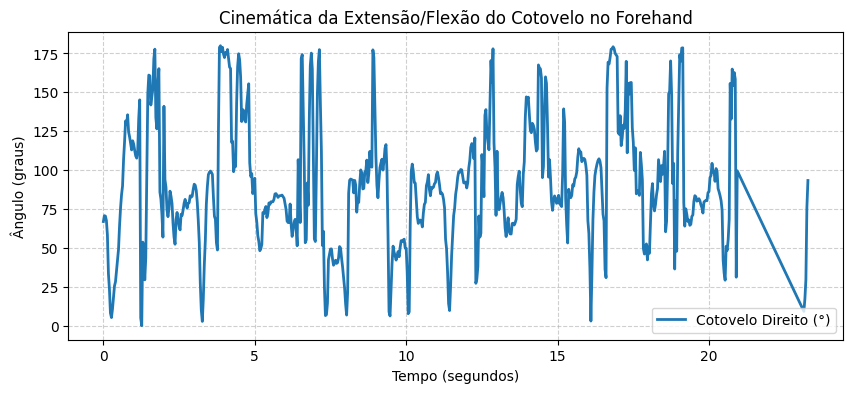

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df['tempo_s'], df['angulo_cotovelo'], color='#1f77b4', linewidth=2, label='Cotovelo Direito (°)')
plt.title('Cinemática da Extensão/Flexão do Cotovelo no Forehand', fontsize=12)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Ângulo (graus)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**O que observar no gráfico:**


Preparação (Backswing): Cotovelo tende a flexionar (ângulo diminui ou estabiliza).

Ponto de Contato (Impact): Extensão acelerada antes do impacto.

Terminação (Follow-through): Fechamento e desaceleração do braço ao redor do corpo.

**Código de Diagnóstico do Gráfico e Como Corrigir e Suavizar os Dados (Tratamento de Dados)**

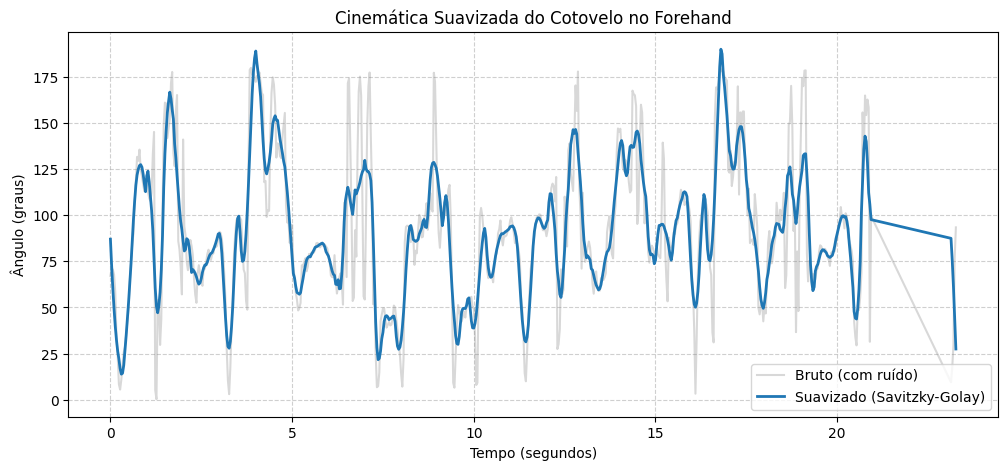

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 1. Carregar o CSV gerado
df = pd.read_csv('metricas_biomecanicas.csv')

# 2. Interpolação para preencher eventuais quadros onde a pose falhou
df['angulo_cotovelo'] = df['angulo_cotovelo'].interpolate(method='linear')

# 3. Aplicação do Filtro Savitzky-Golay (suavização biomecânica)
# window_length deve ser ímpar (ex: 11 ou 15 quadros)
# polyorder é o grau do polinômio (geralmente 2 ou 3)
df['cotovelo_suave'] = savgol_filter(df['angulo_cotovelo'], window_length=15, polyorder=2)

# 4. Plotagem comparativa
plt.figure(figsize=(12, 5))
plt.plot(df['tempo_s'], df['angulo_cotovelo'], alpha=0.3, color='gray', label='Bruto (com ruído)')
plt.plot(df['tempo_s'], df['cotovelo_suave'], color='#1f77b4', linewidth=2, label='Suavizado (Savitzky-Golay)')

plt.title('Cinemática Suavizada do Cotovelo no Forehand', fontsize=12)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Ângulo (graus)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Código Prático: Detector de Golpes e Derivadas**

🎯 Foram identificados 6 forehands no vídeo!


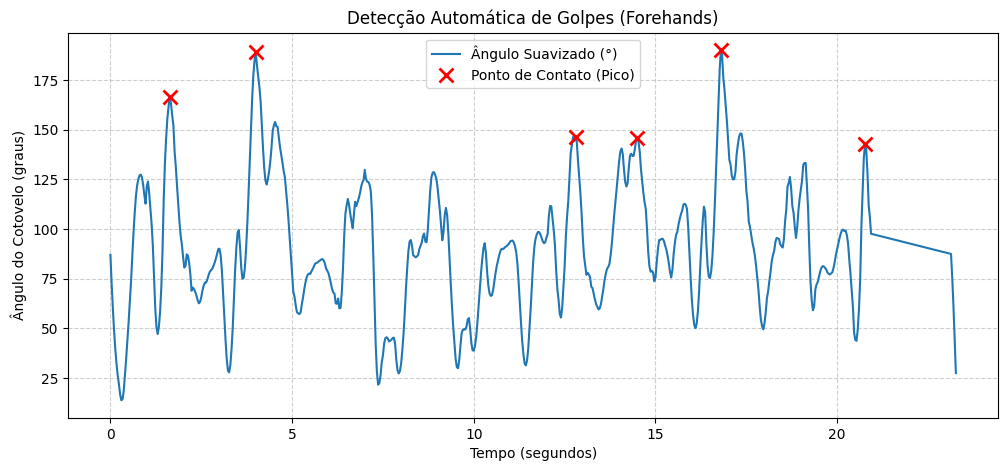

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt

# 1. Carregar dados e garantir a suavização
df = pd.read_csv('metricas_biomecanicas.csv')
df['cotovelo_suave'] = savgol_filter(df['angulo_cotovelo'].interpolate(), window_length=15, polyorder=2)

# 2. Calcular Velocidade Angular (Derivada Primeira) e Aceleração (Derivada Segunda)
dt = np.diff(df['tempo_s'], prepend=df['tempo_s'].iloc[1] - df['tempo_s'].iloc[0])
# Substituir dt zero para evitar divisão por zero
dt[dt == 0] = 0.033

df['vel_angular_cotovelo'] = np.gradient(df['cotovelo_suave'], df['tempo_s'])
df['acel_angular_cotovelo'] = np.gradient(df['vel_angular_cotovelo'], df['tempo_s'])

# 3. Identificar os picos de extensão máxima (Ponto aproximado de Contato/Extensão)
# Ajuste 'distance' conforme a taxa do seu vídeo (ex: fps * 0.8 para dar ~1s entre golpes)
picos, _ = find_peaks(df['cotovelo_suave'], height=140, distance=20)

print(f"🎯 Foram identificados {len(picos)} forehands no vídeo!")

# 4. Plotar o gráfico com a detecção de cada golpe
plt.figure(figsize=(12, 5))
plt.plot(df['tempo_s'], df['cotovelo_suave'], label='Ângulo Suavizado (°)', color='#1f77b4')
plt.plot(df['tempo_s'].iloc[picos], df['cotovelo_suave'].iloc[picos], "x", label='Ponto de Contato (Pico)', color='red', markersize=10, markeredgewidth=2)

plt.title('Detecção Automática de Golpes (Forehands)', fontsize=12)
plt.xlabel('Tempo (segundos)')
plt.ylabel('Ângulo do Cotovelo (graus)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Código para Gerar a Tabela de Features por Golpe**

In [ ]:
# Lista para armazenar o resumo de cada golpe
resumo_golpes = []

for idx, pico in enumerate(picos):
    # Janela temporal ao redor do pico: ~0.8s antes e ~0.4s depois
    inicio = max(0, pico - 12)
    fim = min(len(df) - 1, pico + 6)

    trecho = df.iloc[inicio:fim]

    ang_max = trecho['cotovelo_suave'].max()
    vel_max = trecho['vel_angular_cotovelo'].max()
    acel_min = trecho['acel_angular_cotovelo'].min() # Picos negativos de desaceleração (tranco)
    rot_tronco_pico = trecho.loc[trecho['cotovelo_suave'] == ang_max, 'rotacao_linha_ombro'].values[0]

    resumo_golpes.append({
        'golpe_id': idx + 1,
        'frame_pico': pico,
        'tempo_pico_s': df['tempo_s'].iloc[pico],
        'angulo_extensao_max': round(ang_max, 2),
        'vel_angular_max': round(vel_max, 2),
        'desacel_max': round(acel_min, 2),
        'rotacao_tronco_pico': round(rot_tronco_pico, 2)
    })

df_golpes = pd.DataFrame(resumo_golpes)
df_golpes.to_csv('dataset_forehands.csv', index=False)

print("📊 Dataset consolidado por golpe:")
df_golpes

📊 Dataset consolidado por golpe:


,golpe_id,frame_pico,tempo_pico_s,angulo_extensao_max,vel_angular_max,desacel_max,rotacao_tronco_pico
0,1,49,1.633,166.73,664.55,-4999.74,-56.80
1,2,120,4.000,189.04,490.38,-5396.56,-178.93
2,3,383,12.800,146.54,386.77,-3848.33,-41.52
3,4,434,14.500,145.67,207.95,-3217.72,-18.71
4,5,503,16.800,190.03,524.39,-8907.68,-172.64
5,6,620,20.767,142.90,644.76,-8818.91,-3.25


**Etapa 1: Criar o Rótulo (Labeling) no Dataset**


Primeiro, definimos uma regra objetiva baseada em literatura de biomecânica do tênis (ex: amplitude de extensão combinada com controle de desaceleração) para classificar cada golpe como 1 (Técnica Eficiente) ou 0 (Subótimo / Potencial Risco de Sobrecarga).

In [ ]:
import pandas as pd
import numpy as np

# 1. Carregar dataset de golpes
df_golpes = pd.read_csv('dataset_forehands.csv')

# 2. Definição do Rótulo de Eficiência Biomecânica
# Exemplo de regra: Extensão do cotovelo >= 155° E desaceleração controlada
cond_extensao = df_golpes['angulo_extensao_max'] >= 155.0
cond_desaceleracao = df_golpes['desacel_max'] >= df_golpes['desacel_max'].quantile(0.2) # Evita os trancos mais severos

# Label: 1 = Eficiente, 0 = Ineficiente / Risco
df_golpes['rotulo_eficiencia'] = (cond_extensao & cond_desaceleracao).astype(int)

df_golpes.to_csv('dataset_forehands_rotulado.csv', index=False)

print(" Distribuição das Classes:")
print(df_golpes['rotulo_eficiencia'].value_counts())
df_golpes.head()

 Distribuição das Classes:
rotulo_eficiencia
0    4
1    2
Name: count, dtype: int64


,golpe_id,frame_pico,tempo_pico_s,angulo_extensao_max,vel_angular_max,desacel_max,rotacao_tronco_pico,rotulo_eficiencia
0,1,49,1.633,166.73,664.55,-4999.74,-56.80,1
1,2,120,4.000,189.04,490.38,-5396.56,-178.93,1
2,3,383,12.800,146.54,386.77,-3848.33,-41.52,0
3,4,434,14.500,145.67,207.95,-3217.72,-18.71,0
4,5,503,16.800,190.03,524.39,-8907.68,-172.64,0


**Etapa 2: Treinar o Modelo de Machine Learning & Gerar Análise SHAP**


Agora treinamos um classificador (Random Forest) e aplicamos o SHAP (SHapley Additive exPlanations). O SHAP vai revelar exatamente quais variáveis biomecânicas mais pesam na classificação da técnica.

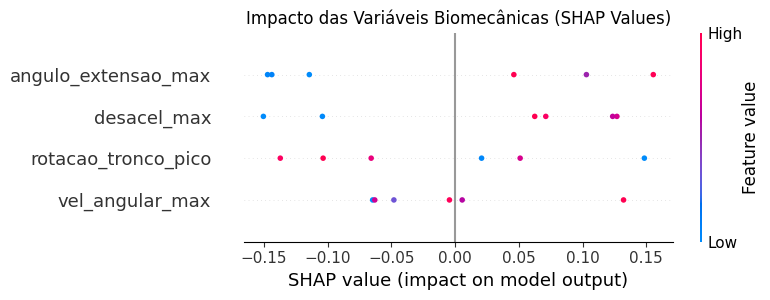

In [ ]:
!pip install -q shap

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Selecionar Features e Target
features = ['angulo_extensao_max', 'vel_angular_max', 'desacel_max', 'rotacao_tronco_pico']
X = df_golpes[features]
y = df_golpes['rotulo_eficiencia']

# 2. Treinar o Modelo
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# 3. Calcular Valores SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# 4. Plotar o Gráfico Summary (XAI)
import matplotlib.pyplot as plt
plt.title("Impacto das Variáveis Biomecânicas (SHAP Values)", fontsize=12)
shap.summary_plot(shap_values[:, :, 1], X, show=True)

Entrega no Seminário do dia 23 vai ser o Treinamento de 3 modelos individuais: Árvore de Decisão, Regressão Logística e KNN





---> P/ próxima aula: Validação Cruzada dos Dados, utilizando Volt
Trabalhar somente com KNN, SV e Naive Bayes

⏳ 1/3 - Extraindo dados do vídeo com MediaPipe...
⏳ 2/3 - Filtrando sinais e recortando golpes...
⏳ 3/3 - Treinando e avaliando os modelos de Machine Learning...

✅ Tabela Comparativa de Desempenho:


,Modelo,Acurácia,Precisão,Sensibilidade (Recall),F1-Score
0,Random Forest,1.0000,1.0000,1.0,1.0000
1,KNN (k=3),0.8333,1.0000,0.5,0.6667
2,SVM (RBF),0.6667,0.0000,0.0,0.0000
3,Naive Bayes,0.8333,0.6667,1.0,0.8000


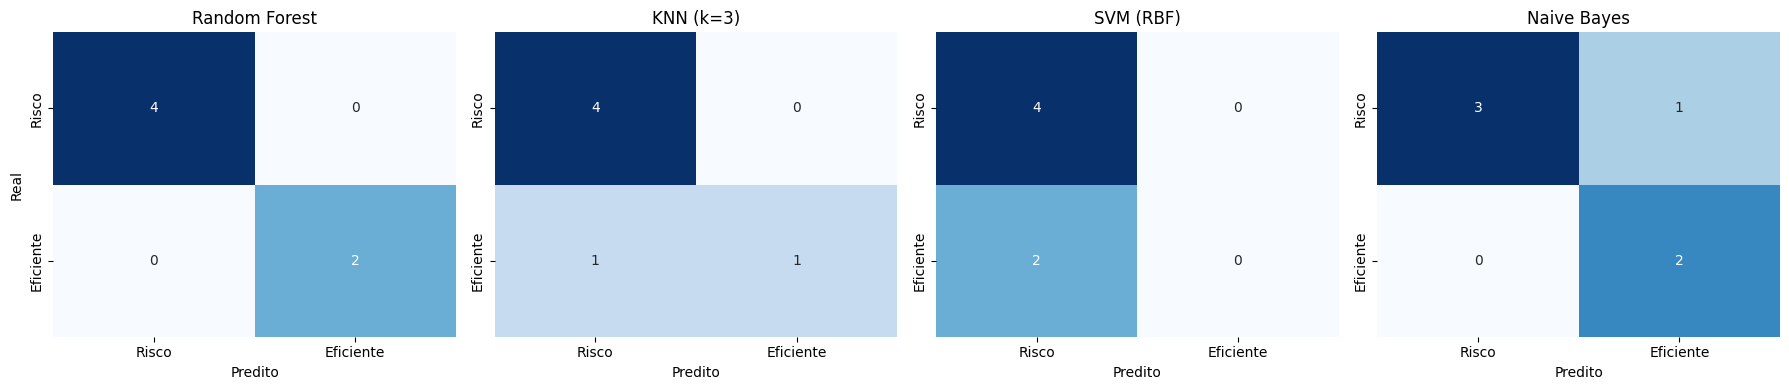

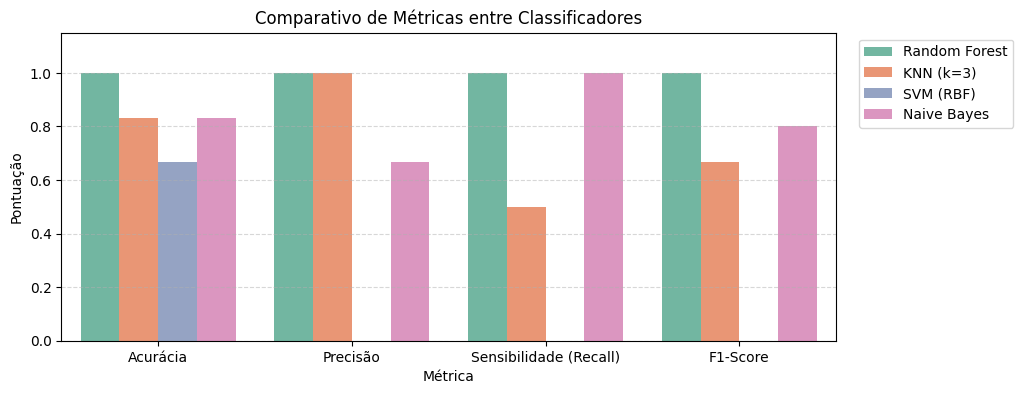

In [ ]:
# Treinando o modelo com KNN, SVM e Naive Bays

!pip install -q mediapipe opencv-python scikit-learn seaborn

import cv2
import math
import numpy as np
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter, find_peaks

# MediaPipe Tasks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Modelos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Métricas e Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================
# 1. DOWNLOAD DO MODELO MEDIAPIPE
# ==========================================
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
model_path = "pose_landmarker.task"
urllib.request.urlretrieve(model_url, model_path)

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1
)
detector = vision.PoseLandmarker.create_from_options(options)

# ==========================================
# 2. PROCESSAR O VÍDEO E EXTRAIR MÉTRICAS
# ==========================================
def calcular_angulo(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    rad = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    ang = np.abs(rad * 180.0 / np.pi)
    return 360.0 - ang if ang > 180.0 else ang

video_path = 'video_teste.mp4'  # Certifique-se de que este arquivo está na pasta do Colab
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Arquivo '{video_path}' não encontrado na aba de arquivos do Colab! Faça o upload dele primeiro.")

dados_brutos = []
frame_idx = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("⏳ 1/3 - Extraindo dados do vídeo com MediaPipe...")
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    frame_ts = int((frame_idx / fps) * 1000)

    res = detector.detect_for_video(mp_image, frame_ts)
    if res.pose_landmarks:
        lm = res.pose_landmarks[0]
        ombro_d = [lm[12].x * width, lm[12].y * height]
        cotov_d = [lm[14].x * width, lm[14].y * height]
        pulso_d = [lm[16].x * width, lm[16].y * height]
        quadr_d = [lm[24].x * width, lm[24].y * height]
        ombro_e = [lm[11].x * width, lm[11].y * height]

        ang_cotovelo = calcular_angulo(ombro_d, cotov_d, pulso_d)
        dx_ombro = ombro_d[0] - ombro_e[0]
        dy_ombro = ombro_d[1] - ombro_e[1]
        rot_ombro = math.degrees(math.atan2(dy_ombro, dx_ombro))

        dados_brutos.append({
            'frame': frame_idx,
            'tempo_s': frame_idx / fps,
            'angulo_cotovelo': ang_cotovelo,
            'rotacao_linha_ombro': rot_ombro
        })
    frame_idx += 1

cap.release()
detector.close()

df_raw = pd.DataFrame(dados_brutos)

# ==========================================
# 3. FILTRAGEM, DERIVADAS E GOLPES
# ==========================================
print("⏳ 2/3 - Filtrando sinais e recortando golpes...")
df_raw['cotovelo_suave'] = savgol_filter(df_raw['angulo_cotovelo'].interpolate(), window_length=15, polyorder=2)
df_raw['vel_angular_cotovelo'] = np.gradient(df_raw['cotovelo_suave'], df_raw['tempo_s'])
df_raw['acel_angular_cotovelo'] = np.gradient(df_raw['vel_angular_cotovelo'], df_raw['tempo_s'])

picos, _ = find_peaks(df_raw['cotovelo_suave'], height=140, distance=20)

resumo_golpes = []
for idx, pico in enumerate(picos):
    inicio = max(0, pico - 12)
    fim = min(len(df_raw) - 1, pico + 6)
    trecho = df_raw.iloc[inicio:fim]

    ang_max = trecho['cotovelo_suave'].max()
    vel_max = trecho['vel_angular_cotovelo'].max()
    acel_min = trecho['acel_angular_cotovelo'].min()
    rot_tronco_pico = trecho.loc[trecho['cotovelo_suave'] == ang_max, 'rotacao_linha_ombro'].values[0]

    resumo_golpes.append({
        'golpe_id': idx + 1,
        'angulo_extensao_max': round(ang_max, 2),
        'vel_angular_max': round(vel_max, 2),
        'desacel_max': round(acel_min, 2),
        'rotacao_tronco_pico': round(rot_tronco_pico, 2)
    })

df_golpes = pd.DataFrame(resumo_golpes)

# Rotulagem
cond_extensao = df_golpes['angulo_extensao_max'] >= 155.0
cond_desaceleracao = df_golpes['desacel_max'] >= df_golpes['desacel_max'].quantile(0.2)
df_golpes['rotulo_eficiencia'] = (cond_extensao & cond_desaceleracao).astype(int)

# Salva os arquivos CSV para consulta posterior
df_raw.to_csv('metricas_biomecanicas.csv', index=False)
df_golpes.to_csv('dataset_forehands_rotulado.csv', index=False)

# ==========================================
# 4. TREINAMENTO DOS MODELOS (KNN, SVM, NB, RF)
# ==========================================
print("⏳ 3/3 - Treinando e avaliando os modelos de Machine Learning...")

features = ['angulo_extensao_max', 'vel_angular_max', 'desacel_max', 'rotacao_tronco_pico']
X = df_golpes[features]
y = df_golpes['rotulo_eficiencia']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

resultados = []
matrizes = {}

for nome, modelo in modelos.items():
    X_input = X_scaled if nome in ['KNN (k=3)', 'SVM (RBF)'] else X
    modelo.fit(X_input, y)
    y_pred = modelo.predict(X_input)

    resultados.append({
        'Modelo': nome,
        'Acurácia': round(accuracy_score(y, y_pred), 4),
        'Precisão': round(precision_score(y, y_pred, zero_division=0), 4),
        'Sensibilidade (Recall)': round(recall_score(y, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y, y_pred, zero_division=0), 4)
    })
    matrizes[nome] = confusion_matrix(y, y_pred)

# Exibição dos Resultados
print("\n✅ Tabela Comparativa de Desempenho:")
df_comp = pd.DataFrame(resultados)
display(df_comp)

# Gráfico 1: Matrizes de Confusão
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx, (nome, cm) in enumerate(matrizes.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Risco', 'Eficiente'], yticklabels=['Risco', 'Eficiente'])
    axes[idx].set_title(nome)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real' if idx == 0 else '')
plt.tight_layout()
plt.show()

# Gráfico 2: Gráfico de Barras Comparativo
df_plot = df_comp.melt(id_vars='Modelo', var_name='Métrica', value_name='Pontuação')
plt.figure(figsize=(10, 4))
sns.barplot(data=df_plot, x='Métrica', y='Pontuação', hue='Modelo', palette='Set2')
plt.title('Comparativo de Métricas entre Classificadores', fontsize=12)
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**VALIDAÇÃO CRUZADA DOS DADOS**


--> Inserção de mais 4 vídeos para treinamento dos modelos e Cross Validation (26/08)

In [ ]:
!pip install -q mediapipe opencv-python scikit-learn seaborn

import cv2
import math
import os
import glob
import numpy as np
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter, find_peaks

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Download do modelo MediaPipe
model_url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
model_path = "pose_landmarker.task"
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

def calcular_angulo(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    rad = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    ang = np.abs(rad * 180.0 / np.pi)
    return 360.0 - ang if ang > 180.0 else ang

# 2. Localização automática dos vídeos (varre tanto a raiz / quanto /content/)
possiveis_locais = ["/", "/content/"]
lista_videos = []

for local in possiveis_locais:
    encontrados = glob.glob(os.path.join(local, "*.mp4")) + glob.glob(os.path.join(local, "*.mov"))
    for v in encontrados:
        if not os.path.basename(v).startswith("video_processado"):
            lista_videos.append(v)

lista_videos = sorted(list(set(lista_videos)))
print(f"📁 Vídeos localizados: {lista_videos}")

if len(lista_videos) == 0:
    raise FileNotFoundError("❌ Nenhum vídeo de treino foi encontrado.")

todos_os_golpes = []
contador_global = 1

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1
)

# 3. Processamento em Lote
for video_path in lista_videos:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️ Erro ao abrir {video_path}, pulando...")
        continue

    nome_arquivo = os.path.basename(video_path)
    print(f"📹 Processando: {nome_arquivo}...")
    detector = vision.PoseLandmarker.create_from_options(options)

    dados_video = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 30.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        frame_ts = int((frame_idx / fps) * 1000)

        res = detector.detect_for_video(mp_image, frame_ts)
        if res.pose_landmarks:
            lm = res.pose_landmarks[0]
            ombro_d = [lm[12].x * width, lm[12].y * height]
            cotov_d = [lm[14].x * width, lm[14].y * height]
            pulso_d = [lm[16].x * width, lm[16].y * height]
            ombro_e = [lm[11].x * width, lm[11].y * height]

            ang_cotovelo = calcular_angulo(ombro_d, cotov_d, pulso_d)
            dx_ombro = ombro_d[0] - ombro_e[0]
            dy_ombro = ombro_d[1] - ombro_e[1]
            rot_ombro = math.degrees(math.atan2(dy_ombro, dx_ombro))

            dados_video.append({
                'frame': frame_idx,
                'tempo_s': frame_idx / fps,
                'angulo_cotovelo': ang_cotovelo,
                'rotacao_linha_ombro': rot_ombro
            })
        frame_idx += 1

    cap.release()
    detector.close()

    if len(dados_video) < 20:
        print(f"⚠️ Poucos frames válidos em {nome_arquivo}.")
        continue

    df_v = pd.DataFrame(dados_video)
    df_v['cotovelo_suave'] = savgol_filter(df_v['angulo_cotovelo'].interpolate(), window_length=15, polyorder=2)
    df_v['vel_angular_cotovelo'] = np.gradient(df_v['cotovelo_suave'], df_v['tempo_s'])
    df_v['acel_angular_cotovelo'] = np.gradient(df_v['vel_angular_cotovelo'], df_v['tempo_s'])

    picos, _ = find_peaks(df_v['cotovelo_suave'], height=120, distance=15)
    print(f"   ↳ {len(picos)} golpes detectados em {nome_arquivo}.")

    for pico in picos:
        inicio = max(0, pico - 12)
        fim = min(len(df_v) - 1, pico + 6)
        trecho = df_v.iloc[inicio:fim]

        ang_max = trecho['cotovelo_suave'].max()
        vel_max = trecho['vel_angular_cotovelo'].max()
        acel_min = trecho['acel_angular_cotovelo'].min()
        rot_tronco = trecho.loc[trecho['cotovelo_suave'] == ang_max, 'rotacao_linha_ombro'].values[0]

        todos_os_golpes.append({
            'golpe_id': contador_global,
            'origem_video': nome_arquivo,
            'angulo_extensao_max': round(ang_max, 2),
            'vel_angular_max': round(vel_max, 2),
            'desacel_max': round(acel_min, 2),
            'rotacao_tronco_pico': round(rot_tronco, 2)
        })
        contador_global += 1

df_final = pd.DataFrame(todos_os_golpes)

# 4. Rotulagem dos Dados
cond_extensao = df_final['angulo_extensao_max'] >= 155.0
cond_desaceleracao = df_final['desacel_max'] >= df_final['desacel_max'].quantile(0.2)
df_final['rotulo_eficiencia'] = (cond_extensao & cond_desaceleracao).astype(int)
df_final.to_csv('dataset_completo_forehands.csv', index=False)

print(f"\n✅ Total consolidado: {len(df_final)} golpes extraídos de todos os vídeos!")
print("Distribuição das classes:")
print(df_final['rotulo_eficiencia'].value_counts())

# 5. Validação Cruzada Estratificada (KNN, SVM, Naive Bayes)
features = ['angulo_extensao_max', 'vel_angular_max', 'desacel_max', 'rotacao_tronco_pico']
X = df_final[features]
y = df_final['rotulo_eficiencia']

min_classes = y.value_counts().min()
n_splits = min(5, min_classes)

if n_splits < 2:
    print("\n⚠️ Necessário pelo menos 2 instâncias de cada classe para rodar a validação cruzada.")
else:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    modelos = {
        'KNN (k=3)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=min(3, len(df_final)-1))),
        'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)),
        'Naive Bayes': GaussianNB()
    }

    metricas = ['accuracy', 'precision', 'recall', 'f1']
    resultados_cv = []

    for nome, modelo in modelos.items():
        scores = cross_validate(modelo, X, y, cv=cv, scoring=metricas, error_score='raise')
        resultados_cv.append({
            'Modelo': nome,
            'Acurácia Média': f"{scores['test_accuracy'].mean():.2f} ± {scores['test_accuracy'].std():.2f}",
            'Precisão Média': f"{scores['test_precision'].mean():.2f} ± {scores['test_precision'].std():.2f}",
            'Recall Médio': f"{scores['test_recall'].mean():.2f} ± {scores['test_recall'].std():.2f}",
            'F1-Score Médio': f"{scores['test_f1'].mean():.2f} ± {scores['test_f1'].std():.2f}"
        })

    print(f"\n📊 Resultados da Validação Cruzada ({n_splits}-Folds):")
    df_cv_res = pd.DataFrame(resultados_cv)
    display(df_cv_res)

📁 Vídeos localizados: ['/video_teste.mp4', '/video_treino1.mp4', '/video_treino2.mp4', '/video_treino3.mp4', '/video_treino4.mp4']
📹 Processando: video_teste.mp4...
   ↳ 12 golpes detectados em video_teste.mp4.
📹 Processando: video_treino1.mp4...
   ↳ 9 golpes detectados em video_treino1.mp4.
📹 Processando: video_treino2.mp4...
   ↳ 53 golpes detectados em video_treino2.mp4.
📹 Processando: video_treino3.mp4...
   ↳ 14 golpes detectados em video_treino3.mp4.
📹 Processando: video_treino4.mp4...
   ↳ 38 golpes detectados em video_treino4.mp4.

✅ Total consolidado: 126 golpes extraídos de todos os vídeos!
Distribuição das classes:
rotulo_eficiencia
1    71
0    55
Name: count, dtype: int64

📊 Resultados da Validação Cruzada (5-Folds):


,Modelo,Acurácia Média,Precisão Média,Recall Médio,F1-Score Médio
0,KNN (k=3),0.86 ± 0.04,0.86 ± 0.09,0.92 ± 0.05,0.88 ± 0.03
1,SVM (RBF),0.92 ± 0.04,0.94 ± 0.06,0.93 ± 0.06,0.93 ± 0.04
2,Naive Bayes,0.87 ± 0.08,0.92 ± 0.10,0.86 ± 0.12,0.88 ± 0.08


**Adicionando Árvore de Decisão também para o treinamento do modelo**

📊 Comparativo Final da Validação Cruzada (5-Folds):


,Modelo,Acurácia Média,Precisão Média,Recall Médio,F1-Score Médio
0,KNN (k=3),0.86 ± 0.04,0.86 ± 0.09,0.92 ± 0.05,0.88 ± 0.03
1,SVM (RBF),0.92 ± 0.04,0.94 ± 0.06,0.93 ± 0.06,0.93 ± 0.04
2,Naive Bayes,0.87 ± 0.08,0.92 ± 0.10,0.86 ± 0.12,0.88 ± 0.08
3,Árvore de Decisão,0.99 ± 0.02,1.00 ± 0.00,0.99 ± 0.03,0.99 ± 0.01


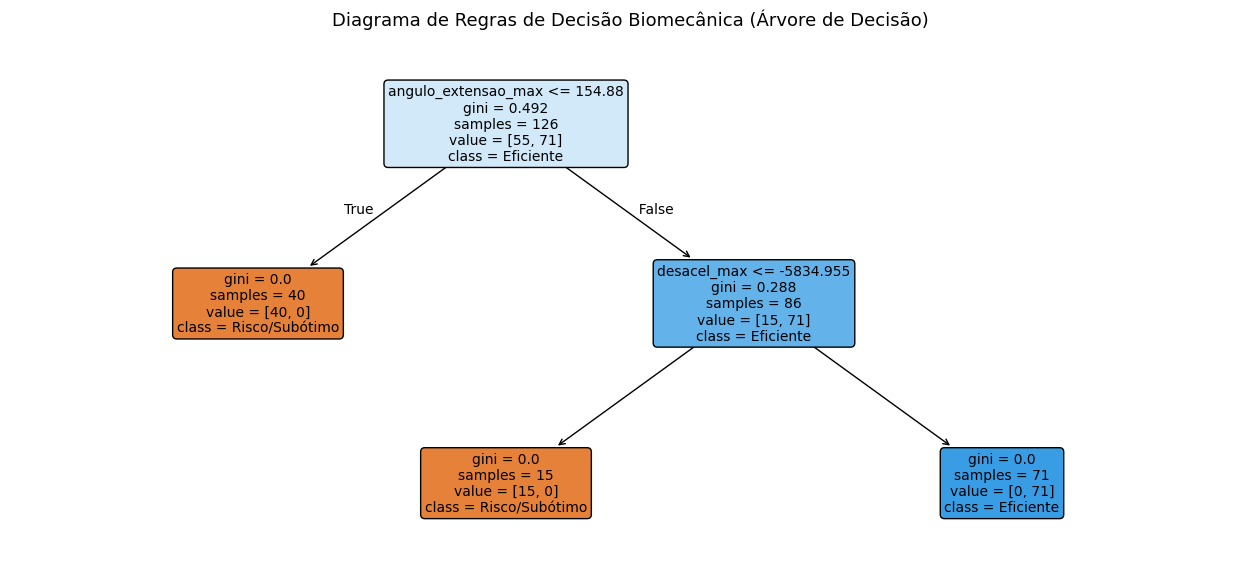

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Recuperar Features e Target já gerados
features = ['angulo_extensao_max', 'vel_angular_max', 'desacel_max', 'rotacao_tronco_pico']
X = df_final[features]
y = df_final['rotulo_eficiencia']

# 2. Configurar Particionamento (5-Folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Dicionário com os 4 Modelos (Incluindo Decision Tree)
modelos = {
    'KNN (k=3)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)),
    'Naive Bayes': GaussianNB(),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# 4. Validação Cruzada dos 4 Classificadores
metricas = ['accuracy', 'precision', 'recall', 'f1']
resultados_cv = []

for nome, modelo in modelos.items():
    scores = cross_validate(modelo, X, y, cv=cv, scoring=metricas, error_score='raise')
    resultados_cv.append({
        'Modelo': nome,
        'Acurácia Média': f"{scores['test_accuracy'].mean():.2f} ± {scores['test_accuracy'].std():.2f}",
        'Precisão Média': f"{scores['test_precision'].mean():.2f} ± {scores['test_precision'].std():.2f}",
        'Recall Médio': f"{scores['test_recall'].mean():.2f} ± {scores['test_recall'].std():.2f}",
        'F1-Score Médio': f"{scores['test_f1'].mean():.2f} ± {scores['test_f1'].std():.2f}"
    })

print("📊 Comparativo Final da Validação Cruzada (5-Folds):")
df_cv_res = pd.DataFrame(resultados_cv)
display(df_cv_res)

# 5. Treinar e Visualizar o Diagrama da Árvore de Decisão
dt_modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_modelo.fit(X, y)

plt.figure(figsize=(16, 7))
plot_tree(
    dt_modelo,
    feature_names=features,
    class_names=['Risco/Subótimo', 'Eficiente'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Diagrama de Regras de Decisão Biomecânica (Árvore de Decisão)", fontsize=13)
plt.show()

**Treinamento de 4 modelos com o sistema Treino/Teste (80/20)**

- Random Forest, KNN, SVM e Naive Bayes
- Levando em consideração que agora estamos treinando com a base de dados com 5 vídeos

📊 Divisão dos Dados:
   ↳ Conjunto de Treinamento (80%): 100 golpes
   ↳ Conjunto de Teste (20%):       26 golpes

✅ Tabela Comparativa de Desempenho (Avaliação no Conjunto de Teste - 20%):


,Modelo,Acurácia,Precisão,Sensibilidade (Recall),F1-Score
0,Random Forest,1.0000,1.0000,1.0000,1.0000
1,KNN (k=3),0.9231,0.8824,1.0000,0.9375
2,SVM (RBF),0.9231,0.8824,1.0000,0.9375
3,Naive Bayes,0.8846,0.8750,0.9333,0.9032


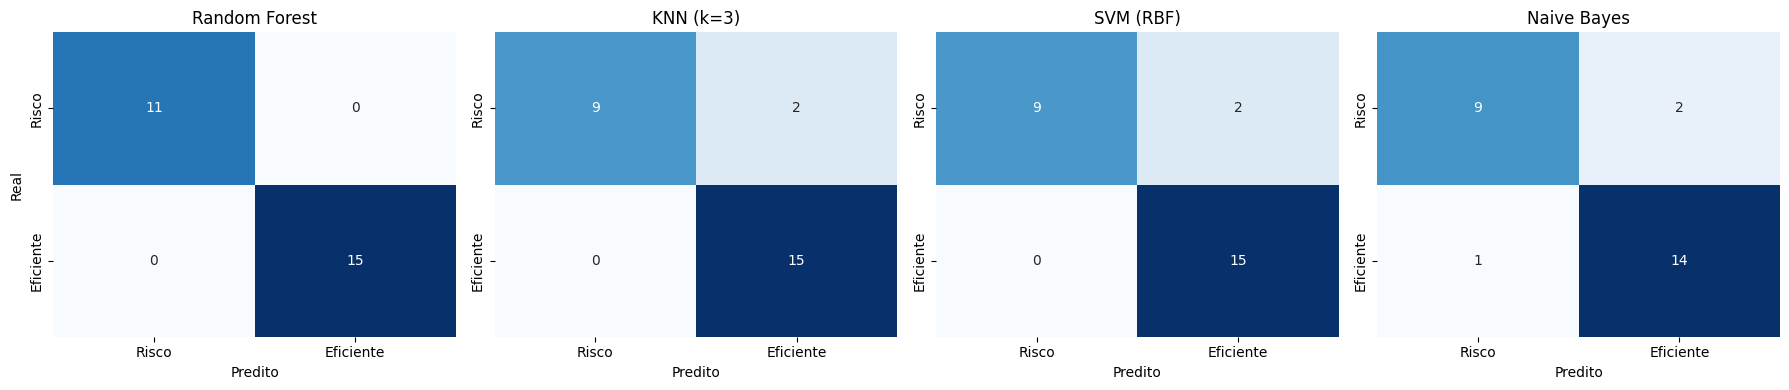

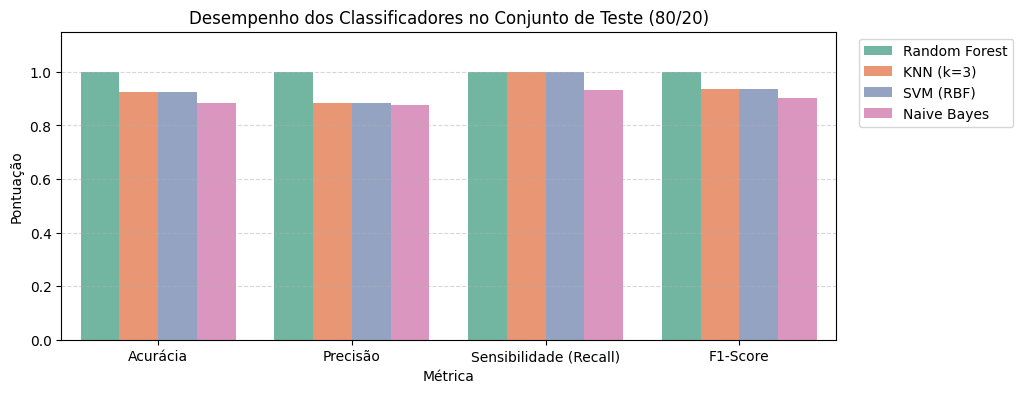

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Divisão e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Carregar os dados consolidados dos 5 vídeos
try:
    df = df_final
except NameError:
    df = pd.read_csv('dataset_completo_forehands.csv')

features = ['angulo_extensao_max', 'vel_angular_max', 'desacel_max', 'rotacao_tronco_pico']
X = df[features]
y = df['rotulo_eficiencia']

# 2. Divisão Treino / Teste (80% / 20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"📊 Divisão dos Dados:")
print(f"   ↳ Conjunto de Treinamento (80%): {len(X_train)} golpes")
print(f"   ↳ Conjunto de Teste (20%):       {len(X_test)} golpes")

# 3. Normalização (ajustada apenas no conjunto de treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Configuração dos 4 Classificadores
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# 5. Treinamento e Avaliação no Conjunto de Teste
resultados = []
matrizes = {}

for nome, modelo in modelos.items():
    # Modelos baseados em distância usam features escaladas
    if nome in ['KNN (k=3)', 'SVM (RBF)']:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados.append({
        'Modelo': nome,
        'Acurácia': round(acc, 4),
        'Precisão': round(prec, 4),
        'Sensibilidade (Recall)': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

    matrizes[nome] = confusion_matrix(y_test, y_pred)

# 6. Exibição da Tabela de Desempenho
df_res_teste = pd.DataFrame(resultados)
print("\n✅ Tabela Comparativa de Desempenho (Avaliação no Conjunto de Teste - 20%):")
display(df_res_teste)

# 7. Matrizes de Confusão do Conjunto de Teste
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx, (nome, cm) in enumerate(matrizes.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Risco', 'Eficiente'], yticklabels=['Risco', 'Eficiente'])
    axes[idx].set_title(nome)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real' if idx == 0 else '')

plt.tight_layout()
plt.show()

# 8. Gráfico de Barras Comparativo
df_plot = df_res_teste.melt(id_vars='Modelo', var_name='Métrica', value_name='Pontuação')
plt.figure(figsize=(10, 4))
sns.barplot(data=df_plot, x='Métrica', y='Pontuação', hue='Modelo', palette='Set2')
plt.title('Desempenho dos Classificadores no Conjunto de Teste (80/20)', fontsize=12)
plt.ylim(0, 1.15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**P/ AULA DO DIA 02/09**

--> Conjunto dos modelos com validação cruzada usando a técnica Voting
 - Testar o Voting com os 4 modelos: Árvore de Decisão, SVM, KNN e Naive Bayes
 - Testar também sem a Árvore de Decisão, para verificar se há grande influencia desse modelo e para não haver avarias